# Install dan Import Library

In [ ]:
!pip uninstall community
!pip install python-louvain


In [ ]:
import networkx as nx
import community.community_louvain as community_louvain
import matplotlib.pyplot as plt
import pandas as pd


#Load Dataset

In [ ]:
# 1. Load Edge List

file_path = "/content/drive/MyDrive/PPW/facebook_combined.txt"

print("Loading dataset...")
G = nx.read_edgelist(file_path, nodetype=int)
print("Total Nodes :", G.number_of_nodes())
print("Total Edges :", G.number_of_edges())


Loading dataset...
Total Nodes : 4039
Total Edges : 88234


#Algoritma Louvain

In [ ]:
# 2. Louvain Community Detection

print("\nRunning Louvain algorithm...")

partition = community_louvain.best_partition(G)

num_communities = len(set(partition.values()))
print("Total Communities Detected:", num_communities)



Running Louvain algorithm...
Total Communities Detected: 16


#Mengitung Modularity

In [ ]:
# 5. Hitung Modularity
from community.community_louvain import modularity

mod_value = modularity(partition, G)
print("\nModularity Score :", mod_value)



Modularity Score : 0.834955515974416


#Menyimpan Hasil csv

In [ ]:
# 3. Save Results

df = pd.DataFrame({
    "node": list(partition.keys()),
    "community": list(partition.values())
})

df.to_csv("/content/drive/MyDrive/PPW/facebook_louvain_result.csv", index=False)
print("\nHasil komunitas disimpan ke: facebook_louvain_result.csv")


Hasil komunitas disimpan ke: facebook_louvain_result.csv


In [ ]:
fb_louvain_result = pd.read_csv("/content/drive/MyDrive/PPW/facebook_louvain_result.csv")
fb_louvain_result

,node,community
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
...,...,...
4034,4034,13
4035,4035,13
4036,4036,13
4037,4037,13


#Visualisasi graph

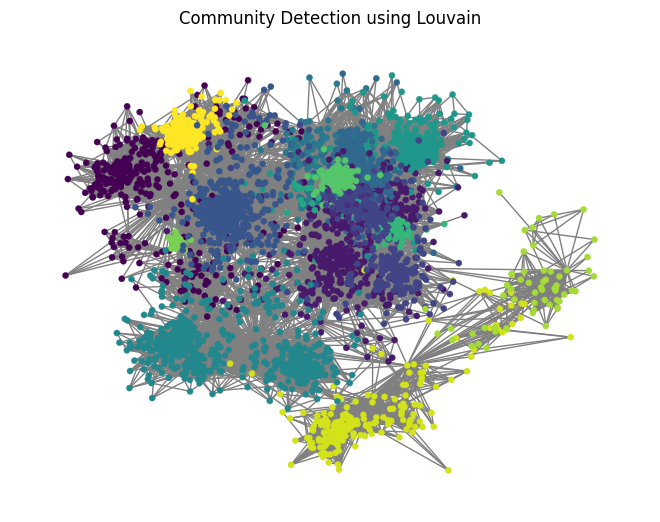

In [ ]:
# 4. (Optional) Visualisasi
visualize = True

if visualize:
    pos = nx.spring_layout(G, seed=42)

    nx.draw(
        G,
        pos,
        node_size=20,
        node_color=[partition[n] for n in G.nodes()],
        cmap=plt.get_cmap("viridis"),
        edge_color="gray",
        linewidths=0.2
    )

    plt.title("Community Detection using Louvain")
    plt.show()


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display

# 1) Load hasil Louvain
path = "/content/drive/MyDrive/PPW/facebook_louvain_result.csv"
df = pd.read_csv(path)

# 2) Hitung ukuran komunitas
community_sizes = Counter(df["community"])

# 3) Buat DataFrame statistik
stats_df = pd.DataFrame({
    "Community ID": list(community_sizes.keys()),
    "Size": list(community_sizes.values())
}).sort_values(by="Size", ascending=False).reset_index(drop=True)

# 4) Statistik ringkasan
total_nodes       = len(df)
total_communities = len(community_sizes)
largest           = stats_df.iloc[0].to_dict()
smallest          = stats_df.iloc[-1].to_dict()
avg_size          = stats_df["Size"].mean()
median_size       = stats_df["Size"].median()
std_size          = stats_df["Size"].std()

summary = {
    "Total Nodes": int(total_nodes),
    "Total Communities": int(total_communities),
    "Largest Community": largest,
    "Smallest Community": smallest,
    "Average Size": float(round(avg_size, 4)),
    "Median Size": float(median_size),
    "Std Dev Size": float(round(std_size, 4))
}

# 5) Tampilkan tabel & ringkasan
print("=== Community Statistics Summary ===")
for k, v in summary.items():
    print(f"{k}: {v}")
print("\n=== Table: community sizes (sorted desc) ===")
display(stats_df)




=== Community Statistics Summary ===
Total Nodes: 4039
Total Communities: 16
Largest Community: {'Community ID': 7, 'Size': 548}
Smallest Community: {'Community ID': 2, 'Size': 19}
Average Size: 252.4375
Median Size: 231.5
Std Dev Size: 187.1947

=== Table: community sizes (sorted desc) ===


,Community ID,Size
0,7,548
1,4,535
2,8,435
3,1,433
4,3,423
5,0,350
6,5,323
7,11,237
8,15,226
9,14,206


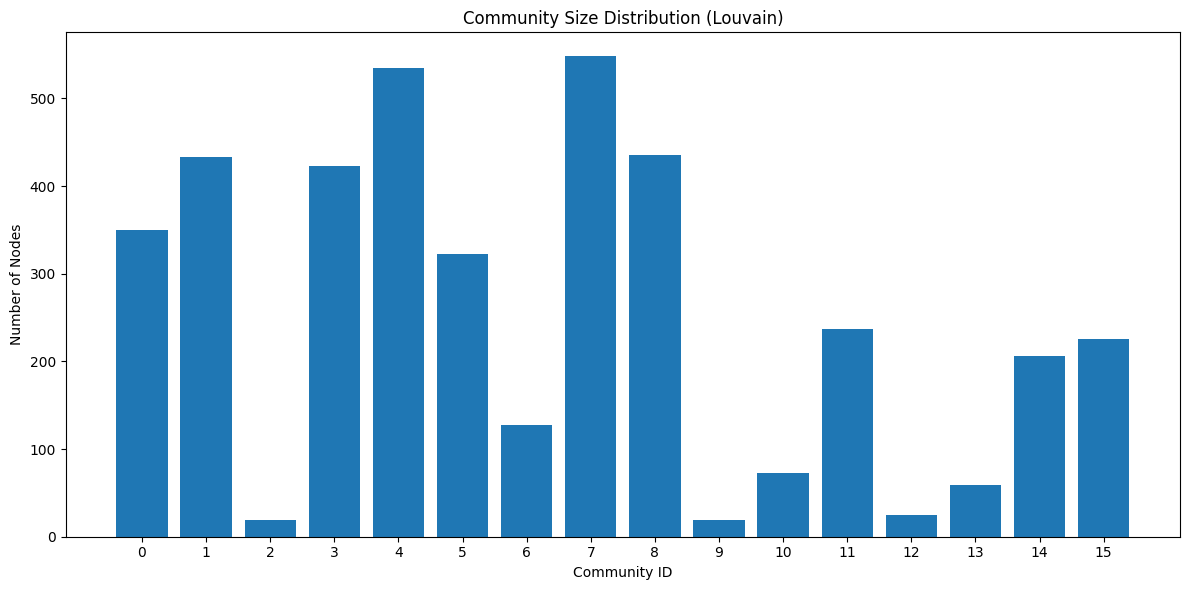

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# Load the uploaded file
path = "/content/drive/MyDrive/PPW/facebook_louvain_result.csv"
df = pd.read_csv(path)

# Count community sizes
community_sizes = Counter(df['community'])

# Prepare data
communities = list(community_sizes.keys())
sizes = list(community_sizes.values())

# Plot
plt.figure(figsize=(12, 6))
plt.bar(communities, sizes)
plt.xlabel("Community ID")
plt.ylabel("Number of Nodes")
plt.title("Community Size Distribution (Louvain)")
plt.xticks(communities)
plt.tight_layout()
plt.show()


#keluarkan semua anggota dari setiap komunitas
#gambar ulang graph dari komunitas terbanyak
#

In [ ]:
import pandas as pd
from collections import defaultdict

# Load hasil Louvain
df = pd.read_csv("/content/drive/MyDrive/PPW/facebook_louvain_result.csv")

# Buat dict untuk menyimpan anggota per komunitas
communities = defaultdict(list)

# Isi anggota
for _, row in df.iterrows():
    communities[row["community"]].append(row["node"])

# Tampilkan hasil
for cid, members in communities.items():
    print(f"\n=== Komunitas {cid} ===")
    print(f"Jumlah anggota: {len(members)}")
    print(members)



=== Komunitas 0 ===
Jumlah anggota: 350
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np

In [ ]:
import os

output_dir = "/content/drive/MyDrive/PPW/komunitas_louvain"
os.makedirs(output_dir, exist_ok=True)

for cid, members in communities.items():
    filename = f"{output_dir}/community_{cid}.txt"
    with open(filename, "w") as f:
        for m in members:
            f.write(str(m) + "\n")

print("Semua file komunitas berhasil dibuat.")


Semua file komunitas berhasil dibuat.


In [ ]:
import pandas as pd
from collections import defaultdict

# Load hasil Louvain
df = pd.read_csv("/content/drive/MyDrive/PPW/facebook_louvain_result.csv")

# Buat dict untuk menyimpan anggota setiap komunitas
communities = defaultdict(list)

# Isi anggota komunitas
for _, row in df.iterrows():
    communities[row["community"]].append(row["node"])

# Cari komunitas terbesar (berdasarkan jumlah anggota)
largest_comm = max(communities, key=lambda c: len(communities[c]))
largest_members = communities[largest_comm]

# Tampilkan hasil komunitas terbesar
print(f"=== Komunitas Terbesar: ID {largest_comm} ===")
print(f"Jumlah anggota: {len(largest_members)}")
print(largest_members)


=== Komunitas Terbesar: ID 7 ===
Jumlah anggota: 548
[np.int64(1085), np.int64(3437), np.int64(3454), np.int64(3487), np.int64(3723), np.int64(3861), np.int64(3961), np.int64(857), np.int64(862), np.int64(865), np.int64(868), np.int64(3456), np.int64(3495), np.int64(3586), np.int64(3621), np.int64(3626), np.int64(3797), np.int64(3501), np.int64(3517), np.int64(3550), np.int64(3577), np.int64(3592), np.int64(3609), np.int64(3633), np.int64(3677), np.int64(3684), np.int64(3721), np.int64(3779), np.int64(3872), np.int64(3948), np.int64(3440), np.int64(3525), np.int64(3540), np.int64(3556), np.int64(3561), np.int64(3651), np.int64(3674), np.int64(3692), np.int64(3741), np.int64(3750), np.int64(3756), np.int64(3830), np.int64(3851), np.int64(3877), np.int64(3886), np.int64(3943), np.int64(3962), np.int64(3438), np.int64(3439), np.int64(3441), np.int64(3442), np.int64(3443), np.int64(3444), np.int64(3445), np.int64(3446), np.int64(3447), np.int64(3448), np.int64(3449), np.int64(3450), np.int

/tmp/ipython-input-2300972012.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


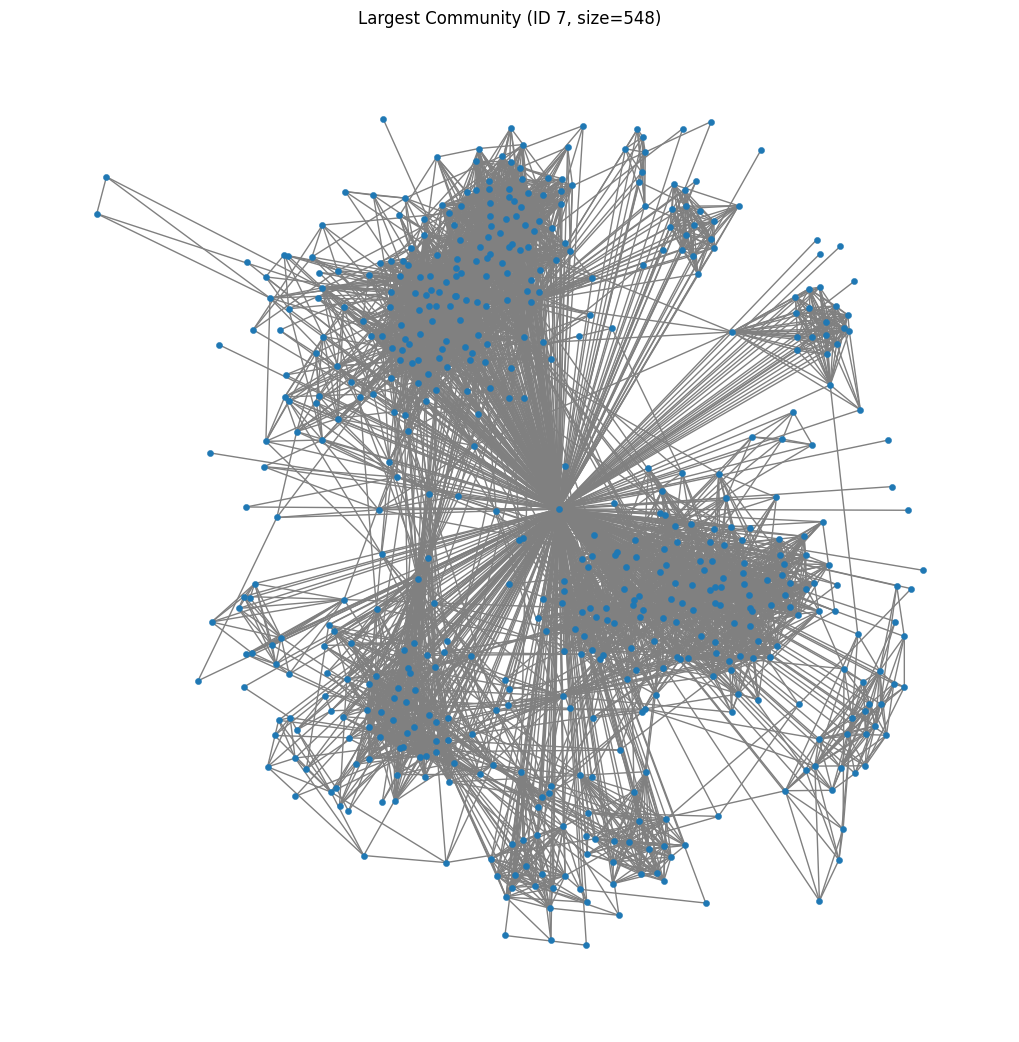

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Load community results and graph
df = pd.read_csv("/content/drive/MyDrive/PPW/facebook_louvain_result.csv")
G = nx.read_edgelist("/content/drive/MyDrive/PPW/facebook_combined.txt", nodetype=int)

# Build community dictionary
communities = defaultdict(list)
for _, row in df.iterrows():
    communities[row["community"]].append(row["node"])

# Identify largest community
largest_comm = max(communities, key=lambda c: len(communities[c]))
largest_members = communities[largest_comm]

# Subgraph for largest community
subG = G.subgraph(largest_members)

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(subG, seed=42)  # stable layout
nx.draw(subG, pos, node_size=20, edge_color="gray", linewidths=0.3)
plt.title(f"Largest Community (ID {largest_comm}, size={len(largest_members)})")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Load data
df = pd.read_csv("/content/drive/MyDrive/PPW/facebook_louvain_result.csv")
G = nx.read_edgelist("/content/drive/MyDrive/PPW/facebook_combined.txt", nodetype=int)

# Group nodes by community
communities = defaultdict(list)
for _, row in df.iterrows():
    communities[row["community"]].append(row["node"])

# Identify largest community
largest_comm = max(communities, key=lambda x: len(communities[x]))

# Plot all communities except largest
for cid, members in communities.items():
    if cid == largest_comm:
        continue

    subG = G.subgraph(members)
    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(subG, seed=42)
    nx.draw(subG, pos, node_size=20, edge_color="gray")
    plt.title(f"Community {cid} (size={len(members)})")
    plt.tight_layout()
    plt.show()


[Lanjut ke Wordgraph](Word_graph_fix.ipynb)